# Some Common Derivatives — Lines

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the derivatives of **constant
and linear functions** (Week 1 — Derivatives and Optimization).

This notebook explains:

- the plan: learn the derivatives of the common function families
- the derivative of a **constant** function is $0$
- the derivative of a **line** $f(x) = ax + b$ is its slope $a$
- the short algebra ($\Delta y/\Delta x$) behind each, verified with SymPy

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Derivatives and Their Notation*.

## 1. Introduction

> *"Our goal is to be able to calculate the derivatives of most of the functions that we
> know. Let's start with the simple ones."*

The common families are: **constants**, **lines**, **quadratics**, **polynomials**,
**exponentials/logarithms**, and **trigonometric** functions. They all have nice, simple
derivatives. This notebook does the two simplest: constants and lines.

## 2. The derivative of a constant

A **constant** function $f(x) = c$ is a horizontal line — the height is the same number $c$
at every $x$ (it could be $-1$, $7$, $3.5$, …).

The tangent at any point has the same slope as the line. Computing it:

$$
\text{slope} = \frac{\Delta y}{\Delta x} = \frac{c - c}{x_1 - x_0} = \frac{0}{x_1 - x_0} = 0 .
$$

The numerator is always $0$ (the height never changes), so

$$
\boxed{\;\frac{d}{dx}\,c = 0.\;}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')
c = sp.symbols('c')

print("d/dx of a constant c:", sp.diff(c, x))   # 0
for val in (-1, 7, 3.5):
    print(f"  d/dx {val} =", sp.diff(sp.Float(val), x))

d/dx of a constant c: 0
  d/dx -1 = 0
  d/dx 7 = 0
  d/dx 3.5 = 0


## 3. The derivative of a line

A general (non-horizontal) line is

$$
f(x) = ax + b,
$$

with slope $a$ and $y$-intercept $b$. Because a line has the **same slope everywhere**, the
tangent at any point is the line itself, of slope $a$:

$$
\boxed{\;\frac{d}{dx}(ax + b) = a.\;}
$$

### The algebra

Take two points, $(x,\, ax+b)$ and $(x+\Delta x,\, a(x+\Delta x)+b)$. Then

$$
\frac{\Delta y}{\Delta x}
= \frac{\big[a(x+\Delta x)+b\big] - \big[ax+b\big]}{\Delta x}
= \frac{ax + a\,\Delta x + b - ax - b}{\Delta x}
= \frac{a\,\Delta x}{\Delta x} = a .
$$

The $ax$ and $b$ cancel, then $\Delta x$ cancels, leaving the slope $a$.

In [2]:
a, b, dx = sp.symbols('a b Delta_x')
slope = ((a*(x + dx) + b) - (a*x + b)) / dx
print("Δy/Δx =", sp.simplify(slope), "  -> the slope a")

# SymPy derivative of ax + b
print("d/dx (a*x + b) =", sp.diff(a*x + b, x))

Δy/Δx = a   -> the slope a
d/dx (a*x + b) = a


### Examples

In [3]:
for expr in [sp.Integer(5), 3*x + 2, -2*x + 7, sp.Rational(1,2)*x - 4]:
    print(f"f(x) = {str(expr):>12}   ->   f'(x) = {sp.diff(expr, x)}")

f(x) =            5   ->   f'(x) = 0
f(x) =      3*x + 2   ->   f'(x) = 3
f(x) =      7 - 2*x   ->   f'(x) = -2
f(x) =      x/2 - 4   ->   f'(x) = 1/2


## 4. Visualizing

A constant is a flat line (slope $0$); a line $ax+b$ has the constant slope $a$ — its
tangent everywhere coincides with the line itself.

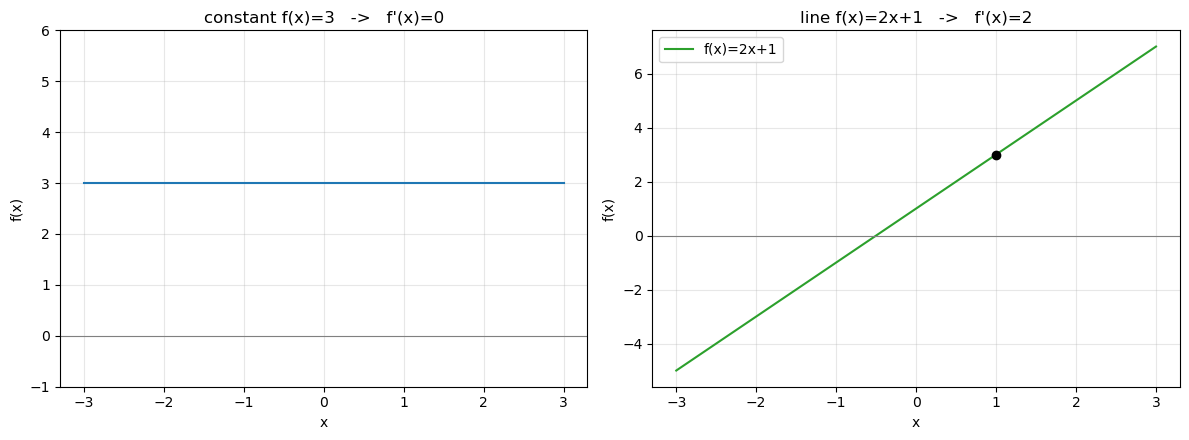

In [4]:
xs = np.linspace(-3, 3, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(xs, 0*xs + 3, color="tab:blue")
axes[0].set_title("constant f(x)=3   ->   f'(x)=0")
axes[0].set_ylim(-1, 6)

a_val, b_val = 2, 1
axes[1].plot(xs, a_val*xs + b_val, color="tab:green", label=f"f(x)={a_val}x+{b_val}")
# tangent at x=1 is the same line (slope a)
axes[1].plot(1, a_val*1+b_val, "ko")
axes[1].set_title(f"line f(x)={a_val}x+{b_val}   ->   f'(x)={a_val}")
axes[1].legend()

for ax in axes:
    ax.axhline(0, color="gray", lw=0.8); ax.set_xlabel("x"); ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Exercises

### Basic
1. What is the derivative of any constant function?
2. What is the derivative of $f(x) = ax + b$?

### Intermediate
3. Find the derivatives of $f(x) = 7$, $g(x) = 4x - 9$, and $h(x) = -x + 2$.
4. A line passes through points with slope $-3$. What is its derivative?

### Advanced
5. Using the limit definition, show that the derivative of $f(x) = ax + b$ is $a$.
6. Explain why the tangent line to any straight line is the line itself.

## 6. Solutions / Checks

In [5]:
x = sp.symbols('x')

# 3.
for expr in (sp.Integer(7), 4*x - 9, -x + 2):
    print("3.", expr, "->", sp.diff(expr, x))

# 5. limit definition
a, b, h = sp.symbols('a b h')
f = a*x + b
limit_def = sp.limit((f.subs(x, x + h) - f) / h, h, 0)
print("5. limit definition of d/dx(ax+b) =", limit_def)

print("1. 0.")
print("2. a (the slope).")
print("4. -3 (the derivative of a line is its slope).")
print("6. A line has the same slope at every point, so its tangent everywhere is the line itself.")

3. 7 -> 0
3. 4*x - 9 -> 4
3. 2 - x -> -1
5. limit definition of d/dx(ax+b) = a
1. 0.
2. a (the slope).
4. -3 (the derivative of a line is its slope).
6. A line has the same slope at every point, so its tangent everywhere is the line itself.


## 7. Conclusion

- The derivative of a **constant** is $0$: a horizontal line never rises, so $\Delta y = 0$.
- The derivative of a **line** $f(x) = ax + b$ is its **slope** $a$: $\Delta y/\Delta x$
  simplifies to $a$ everywhere.
- These are the first entries in the table of common derivatives; **quadratics**,
  **polynomials**, exponentials, logs, and trig functions follow in the next lectures.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (7).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **some common derivatives — lines**. Key spoken points, lightly
cleaned:

> The goal is to compute derivatives of the functions we know — constants, lines,
> quadratics, polynomials, exponentials, logarithms, and trig functions — and they have
> nice simple derivatives. The simplest line is a constant (horizontal line) $f(x) = c$;
> its slope is $\Delta y/\Delta x = (c-c)/(x_1-x_0) = 0$, so a constant has derivative $0$.
> For a general line $f(x) = ax + b$ with slope $a$ and intercept $b$, the tangent at every
> point has the same slope as the line, so $f'(x) = a$. The algebra: with points
> $(x, ax+b)$ and $(x+\Delta x, a(x+\Delta x)+b)$, $\Delta y/\Delta x = (a\,\Delta x)/\Delta
> x = a$ after the $ax$, $b$, and $\Delta x$ terms cancel. So the derivative of $ax + b$ is
> the slope $a$.